In [17]:
!pip install zarr==2.12 'sunpy[all]' s3fs 'numpy<2' dask natsort xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 2.4 MB/s eta 0:00:003.2 MB/s eta 0:00:01


In [1]:
import os
import s3fs
import zarr
import dask.array as da
import numpy as np
from natsort import natsorted
import xarray as xr

import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as cm

# Load Data

# Inspect Data

In [138]:
store = zarr.DirectoryStore('/Users/stefan/sdomlv2_small.zarr/')
root = zarr.open_group(store=store, path='2010', mode='r')

In [139]:
keys = root.keys()

all_channels = []
for key in keys:
    d = da.from_array(root[key])[:6130, ::4, ::4]
    all_channels.append(d)

all_channels = da.stack(all_channels, axis=0)
# all_channels.to_zarr('./all128.zarr')

In [145]:
data = xr.DataArray(all_channels, dims=['channel', 'time', 'x', 'y'],  coords={'channel': (['channel'], list(keys)), 
                    'time': np.arange(all_channels.shape[1]), 'x': np.arange(all_channels.shape[2]), 'y': np.arange(all_channels.shape[3])},
                   name='DN')
data.to_netcdf('all128.nc')

In [254]:
ds = xr.open_dataset('all128.nc')

In [258]:
ds.channel

<xarray.DataArray 'channel' (channel: 9)> Size: 72B
array(['131A', '1600A', '1700A', '171A', '193A', '211A', '304A', '335A', '94A'],
      dtype=object)
Coordinates:
  * channel  (channel) object 72B '131A' '1600A' '1700A' ... '304A' '335A' '94A'

In [255]:
selected_channel = ds['DN'].sel(channel='171A')
selected_channel

<xarray.DataArray 'DN' (time: 6130, x: 128, y: 128)> Size: 402MB
[100433920 values with dtype=float32]
Coordinates:
  * time     (time) int32 25kB 0 1 2 3 4 5 6 ... 6124 6125 6126 6127 6128 6129
  * x        (x) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * y        (y) int32 512B 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
    channel  <U4 16B '171A'

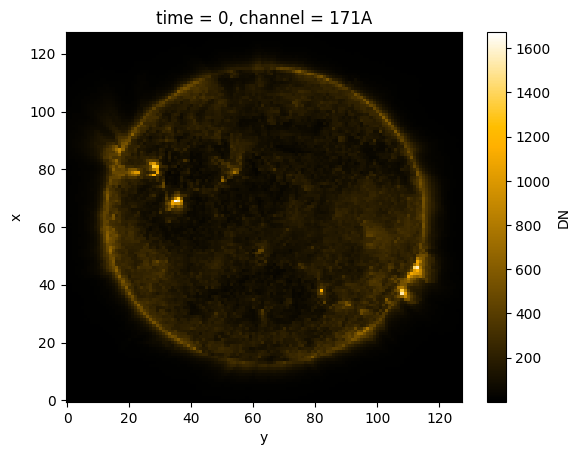

In [259]:
img = selected_channel.isel(time=0)
cmap = plt.get_cmap('sdoaia171')
img.plot(cmap=cmap)


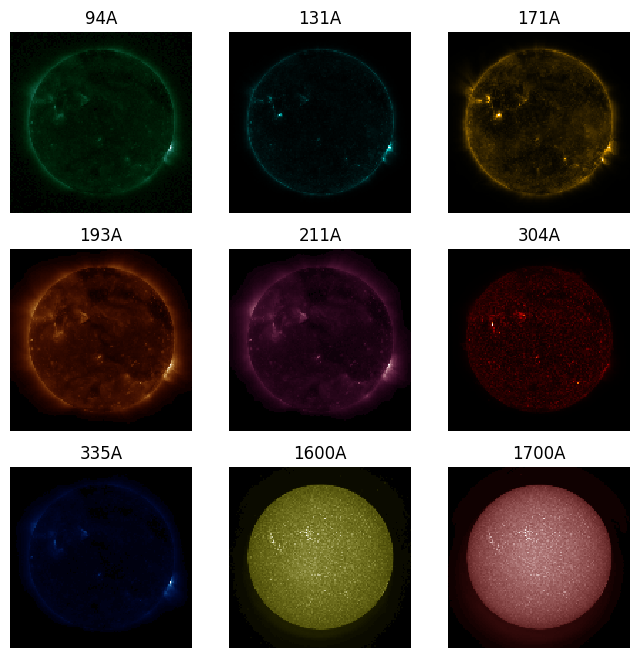

In [260]:
keys = natsorted(ds['channel'].data)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, key in zip(axes.ravel(), keys):
    data = ds['DN'].sel(channel=key).isel(time=0)
    cmap = plt.get_cmap(f'sdoaia{key[:-1]}')
    im = data.plot(cmap=cmap, ax=ax, add_colorbar=False)
    ax.set_title(key)
    ax.axis('off')

plt.show()

# Fun Times

In [198]:
!pip install torch torch_lr_finder

## Create Dataset

In [199]:
from torch.utils.data import Dataset, random_split, DataLoader
import torch
from torch import nn
from torch_lr_finder import LRFinder

/Users/stefan/mambaforge/envs/solar/lib/python3.13/site-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [170]:
class SolarDataset(Dataset):
    def __init__(self, xds):
        self.dataset = xds
        self.X = self.dataset['DN'].sel(channel=['94A', '131A', '171A', '193A', '211A'])
        self.Y = self.dataset['DN'].sel(channel=['304A', '335A', '1600A', '1700A'])


    def __len__(self):
        return self.dataset['DN'].time.shape[0]

    def __getitem__(self, idx):
        x = self.X.isel(time=idx).to_numpy()
        y = self.Y.isel(time=idx).to_numpy()

        x_t = torch.tensor(x)
        y_t = torch.tensor(y)
        
        return x_t, y_t

In [171]:
dataset = SolarDataset(ds)
train_set, test_set, val_set = random_split(dataset, [0.5, 0.25, 0.25])

In [172]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=True)

In [191]:
train_features, train_target = next(iter(train_loader))

In [175]:
train_features.shape

torch.Size([64, 5, 128, 128])

In [176]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [220]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn_stack = nn.Sequential(
            nn.Conv2d(in_channels=5, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=4, kernel_size=3, padding=3)
        )


    def forward(self, x):
        x = self.cnn_stack(x)
        return x

In [221]:
model = CNN().to(device)
print(model)

CNN(
  (cnn_stack): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 4, kernel_size=(3, 3), stride=(1, 1), padding=(3, 3))
  )
)


In [222]:
X = train_features.to(device=device)
y = model(X)
y.shape

torch.Size([64, 4, 128, 128])

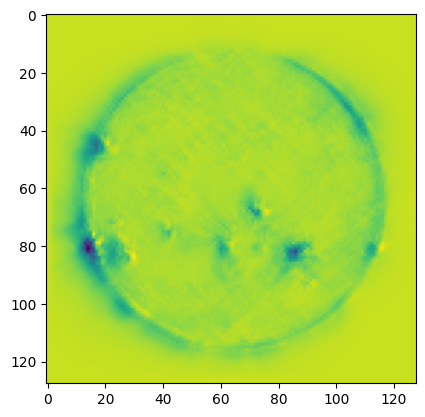

In [223]:
plt.imshow(y[0,0].cpu().detach().numpy())

In [224]:
# Hyper parameters
learning_rate = 1e-4
batch_size = 64
epochs = 10

In [225]:
# Optimizer 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [242]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model.train()
    batch_losses = 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X.to(device=device))
        loss = loss_fn(pred, y.to(device=device))

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # if batch % 100 == 0:
        #     loss = loss.item()
        #     print(f"train loss: {loss:>7f}")
        batch_losses += loss.item()
    return batch_losses / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X.to(device=device))
            test_loss += loss_fn(pred, y.to(device=device)).item()

    test_loss /= num_batches
    print(f"Test Error: \n Avg test loss: {test_loss:>8f} \n")
    return test_loss

In [243]:
model = CNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-2)
lr_finder = LRFinder(model, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=100, num_iter=100)
lr_finder.plot() # to inspect the loss-learning rate graph
lr_finder.reset() # to reset the model and optimizer to their initial state

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [245]:
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1.23e-3, weight_decay=1e-2)
loss_fn = nn.MSELoss()
epochs = 10
train_losses = []
test_losses = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_losses.append(train_loop(train_loader, model, loss_fn, optimizer))
    test_losses.append(test_loop(test_loader, model, loss_fn))
print("Done!")


Epoch 1
-------------------------------
Test Error: 
 Avg test loss: 48282.540202 

Epoch 2
-------------------------------
Test Error: 
 Avg test loss: 38326.832682 

Epoch 3
-------------------------------
Test Error: 
 Avg test loss: 31479.787679 

Epoch 4
-------------------------------
Test Error: 
 Avg test loss: 27497.720378 

Epoch 5
-------------------------------
Test Error: 
 Avg test loss: 25481.860840 

Epoch 6
-------------------------------
Test Error: 
 Avg test loss: 26265.725911 

Epoch 7
-------------------------------
Test Error: 
 Avg test loss: 22154.215495 

Epoch 8
-------------------------------
Test Error: 
 Avg test loss: 21324.399414 

Epoch 9
-------------------------------
Test Error: 
 Avg test loss: 21160.652100 

Epoch 10
-------------------------------
Test Error: 
 Avg test loss: 20040.443278 

Done!


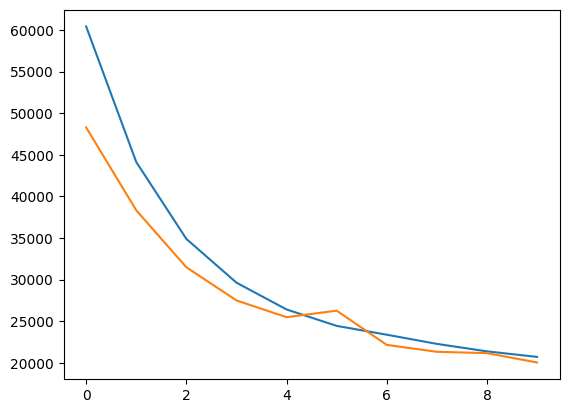

In [246]:
plt.plot(train_losses)
plt.plot(test_losses)

In [247]:

def validate_model(model, val_loader, device):
    """
    Validate the model on the entire validation set using L1 loss.
    
    Args:
        model (torch.nn.Module): Trained PyTorch model.
        val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
        device (torch.device): Device to perform computation on (e.g., 'cuda' or 'cpu').
        
    Returns:
        float: Average L1 loss over the validation set.
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_samples = 0  # Alternatively, you could count total pixels if needed
    
    # Use L1 loss (mean absolute error)
    # Option 1: using reduction 'mean' will average loss over the batch automatically.
    # criterion = torch.nn.L1Loss(reduction='mean')
    #
    # Option 2: using reduction 'sum' and then normalizing by the number of samples:
    criterion = torch.nn.MSELoss(reduction='sum')
    
    with torch.no_grad():  # Disable gradient computation for validation
        for inputs, targets in val_loader:
            # Move data to the appropriate device
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # Forward pass: get predictions from the model
            outputs = model(inputs)
            
            # Compute the loss. With reduction='sum', the loss is summed over the batch.
            loss = criterion(outputs, targets)
            
            # Count the number of samples in this batch
            batch_size = inputs.size(0)
            total_loss += loss.item()
            total_samples += batch_size
    
    # If you used reduction 'sum', normalize by the total number of samples to get the average loss.
    avg_loss = total_loss / total_samples
    print(f"Validation L1 Loss: {avg_loss:.4f}")
    return avg_loss


avg_loss = validate_model(model, val_loader, device)

Validation L1 Loss: 1318755116.7833


In [248]:
val_features, val_target = next(iter(val_loader))

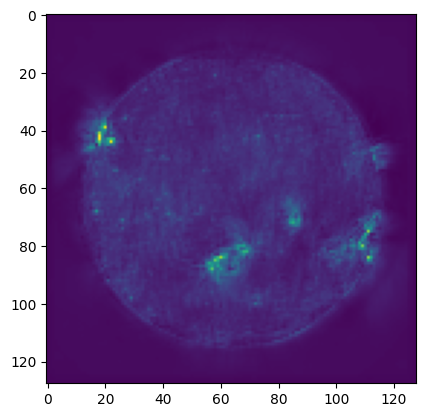

In [252]:
plt.imshow(model(val_features.to(device))[0][0].cpu().detach())

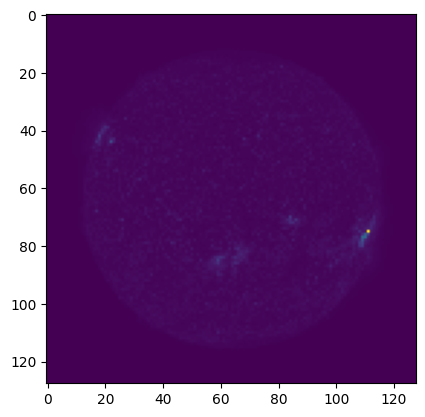

In [253]:
plt.imshow(val_target[0][0])